In [1]:
# Time series plots from Chris' profile files
# The code assumes the files are named after their position on the plot, i.e., top row, column 1, 2, or 3 (see code)
# Lisa Darby May 2026
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import StrMethodFormatter
# Plotting parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 3
plt.rcParams.update({'font.size': 18})

In [2]:
#Plot outfile name
plotfile_csf = 'C:/Users/lisad/OneDrive/Documents/bob_turb/prof_test.jpg'

In [3]:
# List the files to be read in for the plots
top_files = [
    "C:/Users/lisad/OneDrive/Documents/bob_turb/data/Profiles/file_top_1.txt",
    "C:/Users/lisad/OneDrive/Documents/bob_turb/data/Profiles/file_top_2.txt",
    "C:/Users/lisad/OneDrive/Documents/bob_turb/data/Profiles/file_top_3.txt"
]

bottom_files = [
    "C:/Users/lisad/OneDrive/Documents/bob_turb/data/Profiles/file_bottom_1.txt",
    "C:/Users/lisad/OneDrive/Documents/bob_turb/data/Profiles/file_bottom_2.txt",
    "C:/Users/lisad/OneDrive/Documents/bob_turb/data/Profiles/file_bottom_3.txt"
]

all_files = [top_files, bottom_files]

In [4]:
# Specify some of the fields for plotting & simplify names
plot_columns = [
    {   # col 0
        "x": "gw,m2s-8/3",
        "y": "Alt,mAGL",
        "xlo": "gw_lo_err,m2s-8/3",
        "xhi": "gw_hi_err,m2s-8/3"
    },
    {   # col 1
        "x": "eps,m3s-3",
        "y": "Alt,mAGL",
        "xlo": "eps_lo_err,m2s-3",
        "xhi": "eps_hi_err,m2s-3"
    },
    {   # col 2 
        "xmin": "min,s",   
        "xmax": "max,s",
        "x":"min,s",          #placeholder
        "y": "Alt,mAGL"
    }
]

In [5]:
# Set x-axis limits, by column
x_limits = [
    [(0.04, 0.16), (0.0, 0.008), (0.01, 1000)],   # top row
    [(0.04, 0.16), (0.0, 0.008), (0.01, 1000)]    # bottom row
]

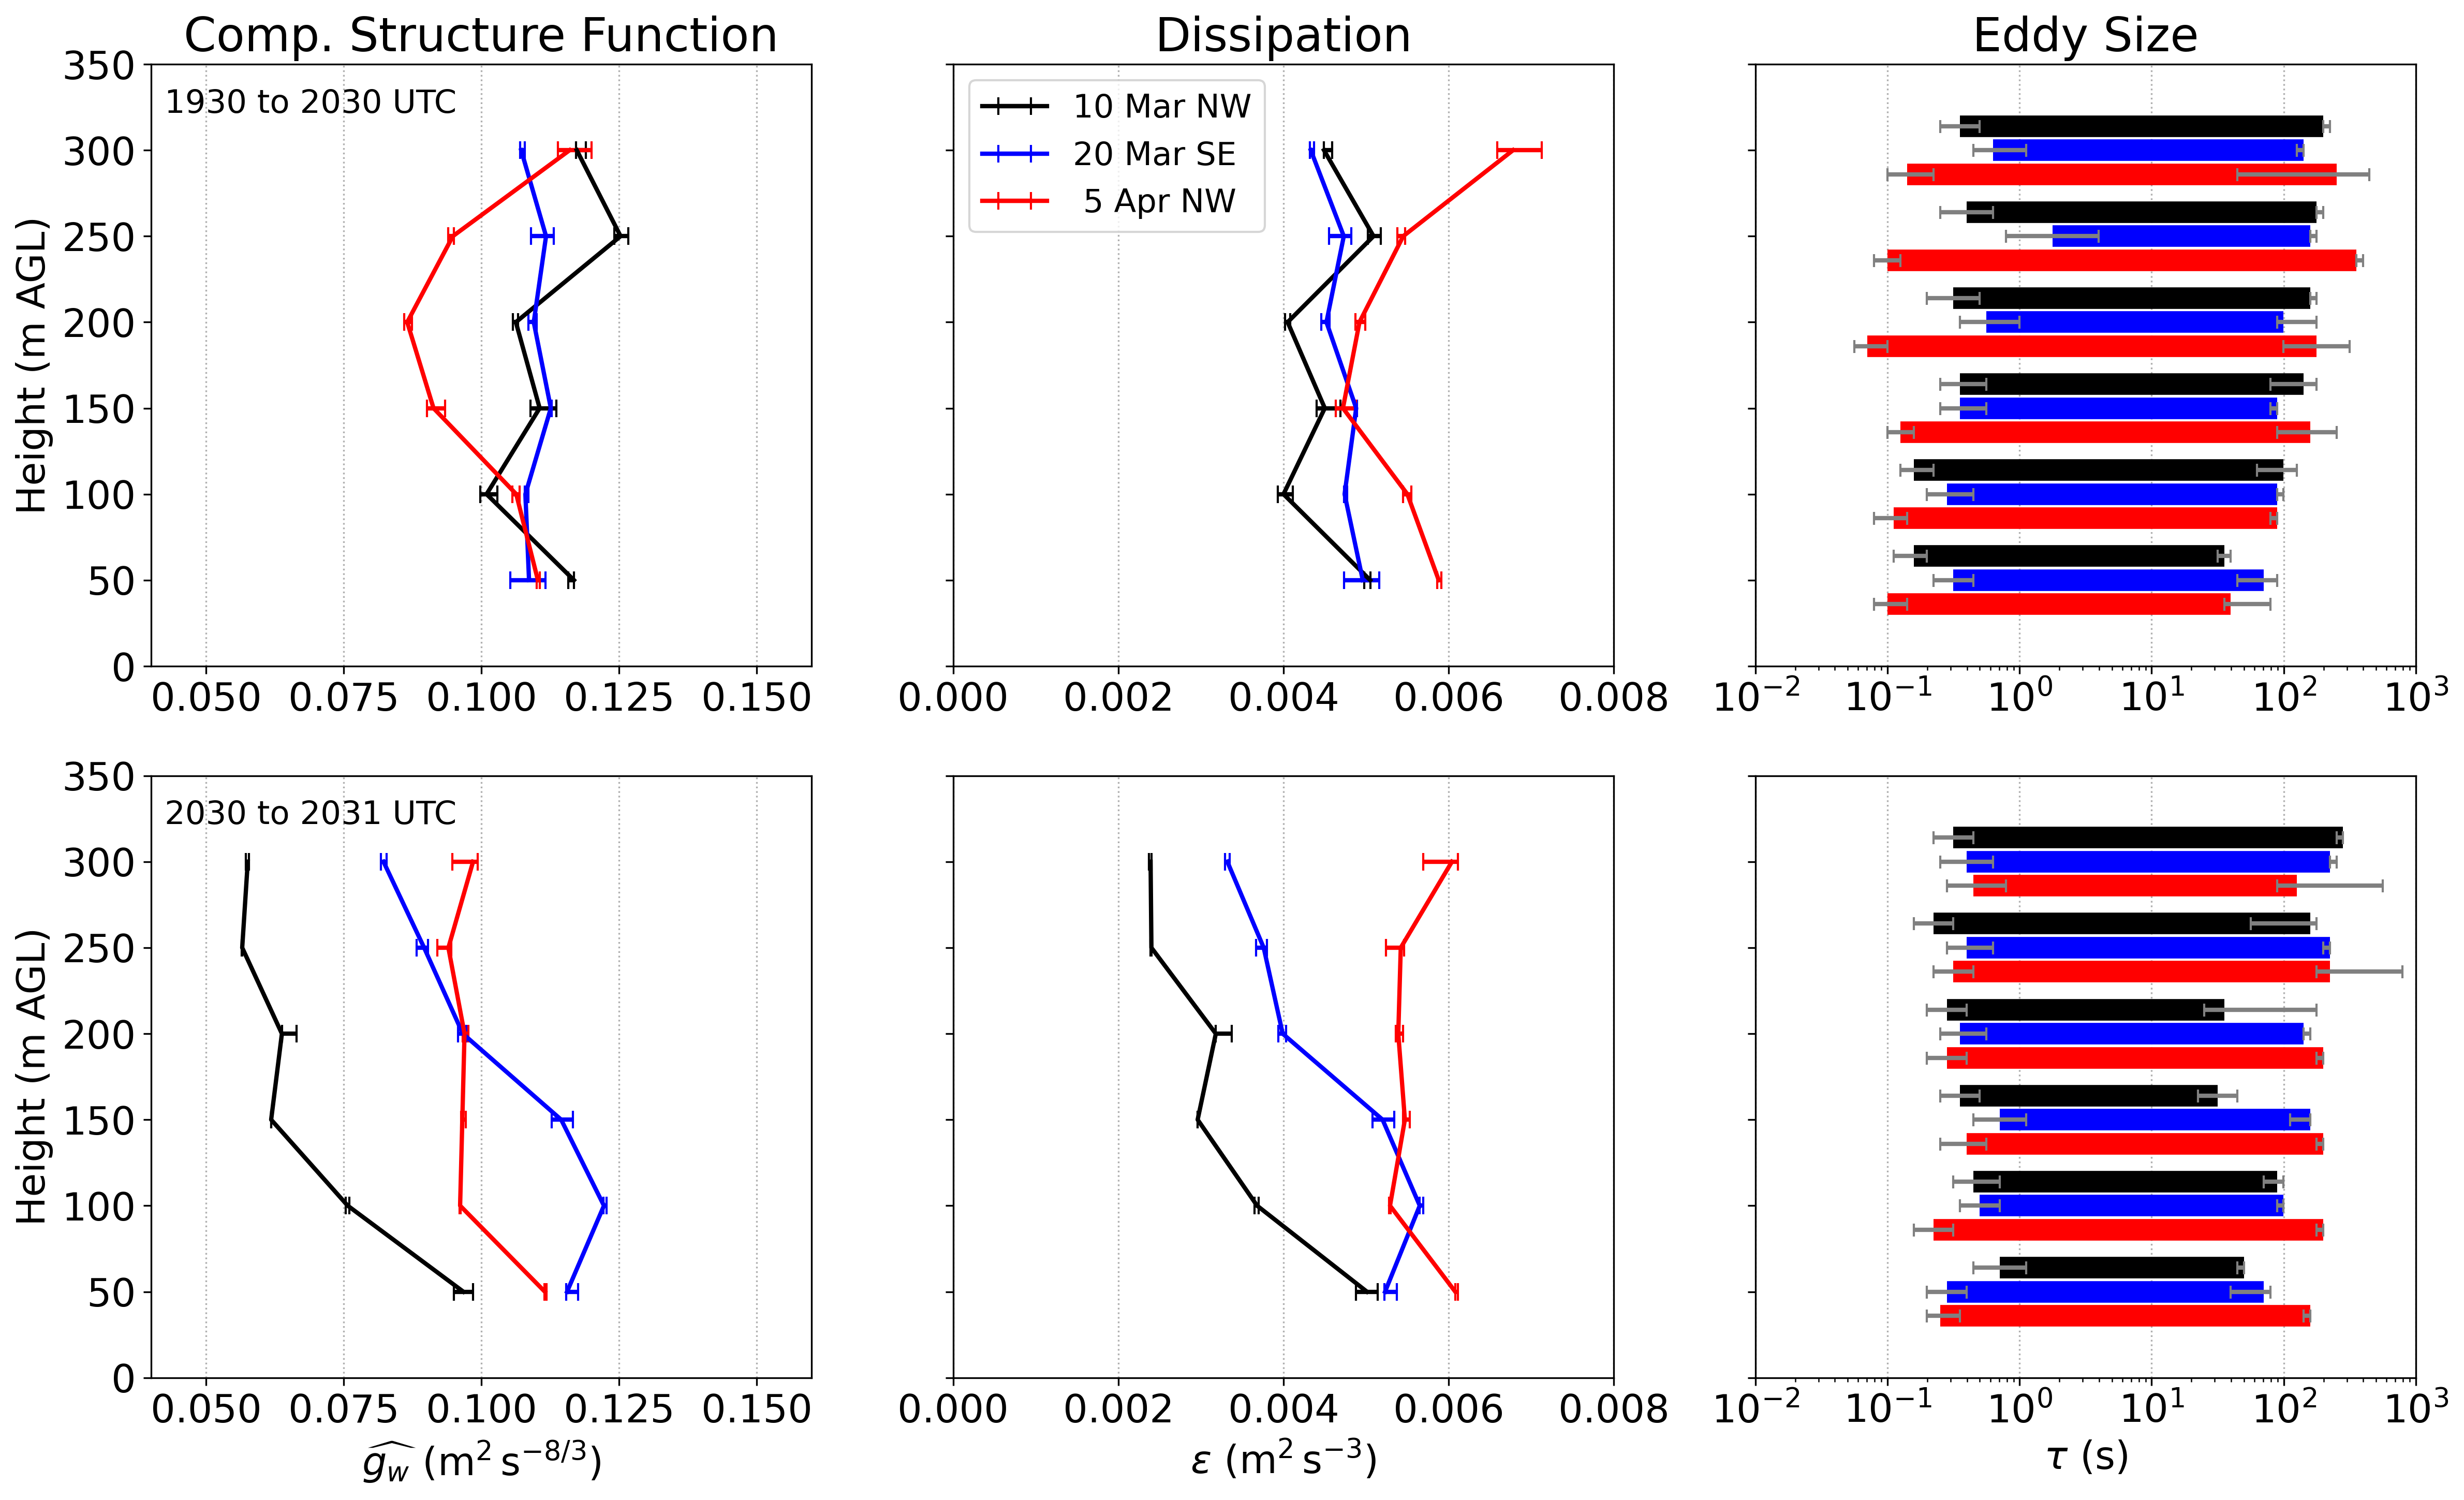

In [6]:
# Create the figure
# Setup the plot size, rows, and columns. Sharey=True means all plots have the same y-axis.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharey=True)

# Setup labels and colors
labels = ["10 Mar NW", "20 Mar SE", " 5 Apr NW"]  # optional
col_titles = ["Comp. Structure Function", "Dissipation", "Eddy Size"]
colors = ["black", "blue", "red"]
x_labs = [r'$\widehat{g_w}\ \left(\mathrm{m^2\,s^{-8/3}}\right)$',
r'$\epsilon\ \left(\mathrm{m^2\,s^{-3}}\right)$',
r'$\tau\ \left(\mathrm{s}\right)$']
row_labels = ['1930 to 2030 UTC', '2030 to 2031 UTC']
offset_base = [1, 0, -1]

# Begin loop to read in files and create the plots. Each panel requires 3 files (one for each day).
for row in range(2):
    for col in range(3):
        ax = axes[row, col]
        config = plot_columns[col]

        for i, file in enumerate(all_files[row]):
            df = pd.read_fwf(file, header=0)

            x = df[config["x"]]
            y = df[config["y"]]
            xmin = df["min,s"]
            xmax = df["max,s"]
            color = colors[i]
            
            if "xlo" in config and "xhi" in config:
                lower = df[config["xlo"]]
                upper = df[config["xhi"]]

                xerr = [
                    x - lower,
                    upper - x
                ]

                ax.errorbar(
                    x, y,
                    xerr=xerr,
                    color=color,
                    capsize=4,
                    label=labels[i]
                )
                ax.set_xlim(x_limits[row][col]),
                
                ax.grid(axis = 'x', linestyle='dotted')
            
            else:
                offset = offset_base[i] * 14  # tune this
                ax.hlines(
                    y=y + offset,
                    xmin=xmin,
                    xmax=xmax,
                    color=colors[i],
                    linewidth=10,
                    label=f"Profile {i+1}"
                )
                ax.errorbar(
                x=xmin,
                y=y + offset,
                xerr=[
                    xmin - df["min_lo_err,s"],
                    df["min_hi_err,s"] - xmin
                ],
                fmt='none',
                ecolor='gray',
                capsize=3
                )
    
                ax.errorbar(
                    x=xmax,
                    y=y + offset,
                    xerr=[
                        xmax - df["max_lo_err,s"],
                        df["max_hi_err,s"] - xmax
                    ],
                    fmt='none',
                    ecolor='gray',
                    capsize=3
                )
                
                ax.set_xlim(x_limits[row][col])
                ax.set_xscale("log")
                ax.grid(axis = 'x', linestyle='dotted')
                
        # formatting
        if row == 0:
            ax.set_title(col_titles[col])
        
        if col == 0:
            ax.set_ylabel('Height (m AGL)')

        if row == 1:
            ax.set_xlabel(x_labs[col])

        #if col == 2:
            #ax.legend()

        if row == 0 and col == 1:
            ax.legend(loc='upper left', fontsize=15)

        if row == 0 and col == 0:
            ax.text(
                0.02, 0.96, row_labels[row],
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=15,
                bbox=dict(facecolor='white', alpha=0.0, edgecolor='none', pad=2)
            )

        if row == 1 and col == 0:
            ax.text(
                0.02, 0.96, row_labels[row],
                transform=ax.transAxes,
                ha='left', va='top',
                fontsize=15,
                bbox=dict(facecolor='white', alpha=0.0, edgecolor='none', pad=2)
            )
            
        ax.yaxis.set_ticks(np.arange(0.0, 400, 50))

plt.tight_layout()

fig.savefig(plotfile_csf, bbox_inches='tight')